In [1]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score
print('Setup complete')

Setup complete


In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
print(train.shape, test.shape)
train_ID = train['Id']
test_ID = test['Id']
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

(1460, 81) (1459, 80)


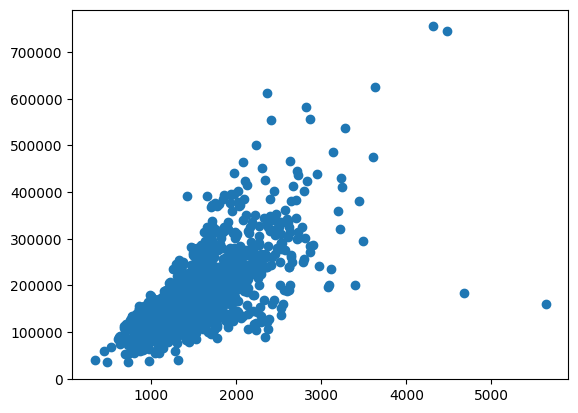

In [3]:
#Remove the extreme data
plt.scatter(x=train['GrLivArea'], y=train['SalePrice'])
plt.show()

In [4]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(f'Id:{list(outliers)}')
train = train.drop(outliers).reset_index(drop=True)

Id:[523, 1298]


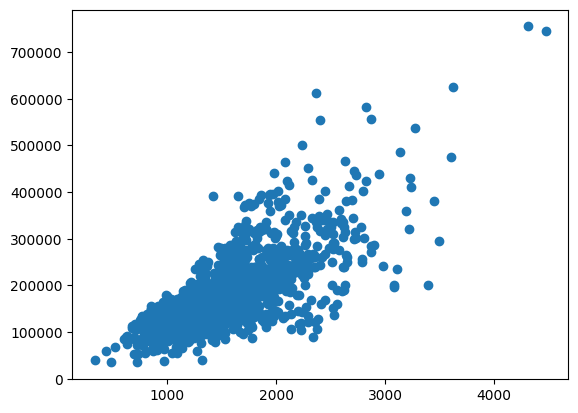

In [5]:
plt.scatter(x=train['GrLivArea'], y=train['SalePrice'])
plt.show()

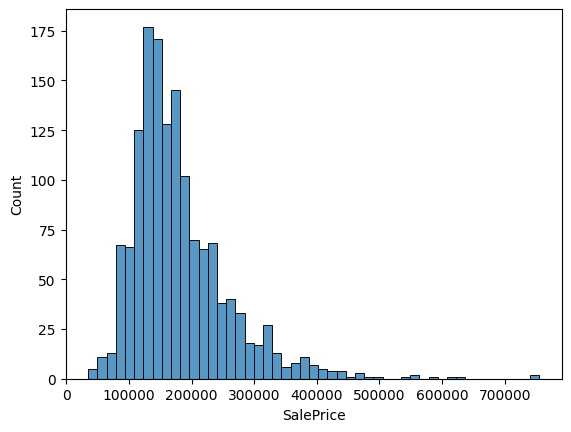

Skewness:1.8812964895244009


In [6]:
#Histogram normalization
sns.histplot(train['SalePrice'])
plt.show()
print(f'Skewness:{train['SalePrice'].skew()}')

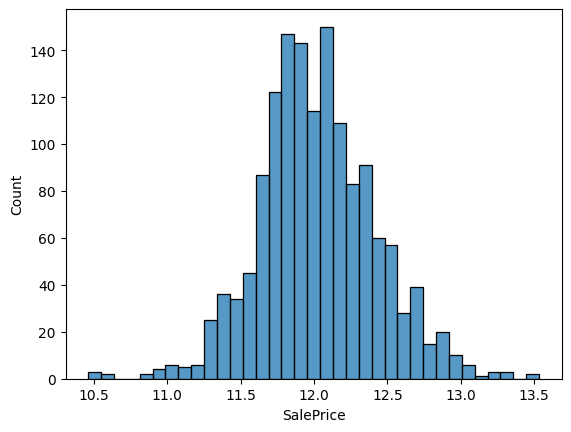

Skewness:0.12157976050304879


In [7]:
train['SalePrice'] = np.log1p(train['SalePrice'])
sns.histplot(train['SalePrice'])
plt.show()
print(f'Skewness:{train['SalePrice'].skew()}')

In [8]:
#Missing values
y_train = train['SalePrice']
X_train = train.drop(['SalePrice'], axis=1)
X_test = test.copy()
all_data = pd.concat([X_train, X_test]).reset_index(drop=True)

missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          2908
MiscFeature     2812
Alley           2719
Fence           2346
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
Functional         2
BsmtHalfBath       2
Utilities          2
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64


In [9]:
categorical_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageQual', 'GarageCond', 'GarageFinish', 'GarageType', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType2', 'BsmtFinType1']
all_data[categorical_cols] = all_data[categorical_cols].fillna('None')

numerical_cols = ['GarageYrBlt', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'GarageArea', 'GarageCars']
all_data[numerical_cols] = all_data[numerical_cols].fillna(0)

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

other_cols = ['MSZoning', 'Functional', 'Exterior2nd', 'Exterior1st', 'Electrical', 'KitchenQual', 'SaleType']
all_data[other_cols] = all_data[other_cols].fillna(all_data[other_cols].mode().iloc[0])

all_data = all_data.drop(['Utilities'], axis=1, errors='ignore')

remaining_missing = all_data.isnull().sum()
print(remaining_missing)

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 78, dtype: int64


In [10]:
#transform
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond',
    'PoolQC'
]

for col in quality_cols:
    all_data[col] = all_data[col].map(quality_map)
print('Finish')

Finish


In [11]:
exposure_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

all_data['BsmtExposure'] = all_data['BsmtExposure'].map(exposure_map)
garage_finish_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

all_data['GarageFinish'] = all_data['GarageFinish'].map(garage_finish_map)
bsmtfin_map = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmtfin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmtfin_map)
check_cols = [
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageFinish'
]

print(all_data[check_cols].isnull().sum())

BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
GarageFinish    0
dtype: int64


In [12]:
fake_numerical_cols = ['MSSubClass', 'MoSold', 'YrSold']
all_data[fake_numerical_cols] = all_data[fake_numerical_cols].astype(str)
print('Finish')

Finish


In [13]:
#new data
all_data['TotalArea'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchArea'] = all_data['OpenPorchSF'] + all_data['3SsnPorch'] + all_data['EnclosedPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']
print('Finish')

Finish


In [14]:
all_data['YrSold'] = pd.to_numeric(all_data['YrSold'], errors='coerce')
all_data['YearBuilt'] = pd.to_numeric(all_data['YearBuilt'], errors='coerce')
all_data['YearRemodAdd'] = pd.to_numeric(all_data['YearRemodAdd'], errors='coerce')

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
print('Finish')

Finish


In [15]:
object_cols = [col for col in all_data.columns if all_data[col].dtype == 'object']
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols = pd.DataFrame(OH_encoder.fit_transform(all_data[object_cols]))
num_data = all_data.drop(object_cols, axis=1)
all_data = pd.concat([num_data, OH_cols], axis=1)
all_data.columns = all_data.columns.astype(str)
print(all_data.shape)

(2917, 273)


In [16]:
#separate
X_train = all_data.iloc[:len(y_train)].copy()
X_test = all_data.iloc[len(y_train):].copy()
print(X_train.shape, y_train.shape, X_test.shape)

(1458, 273) (1458,) (1459, 273)


In [17]:
X_local_train, X_local_val, y_local_train, y_local_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)
my_model = XGBRegressor(random_state=0)
#my_model.fit(X_local_train, y_local_train)
#predictions = my_model.predict(X_local_val)
#rmse_score = np.sqrt(mean_squared_error(y_local_val, predictions))
#print(rmse_score)
cv_scores = -1 * cross_val_score(my_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(cv_scores, cv_scores.mean())

[0.13082689 0.13461685 0.14188481 0.13025561 0.12844806] 0.1332064439310786


In [18]:
#rf_model = RandomForestRegressor(random_state=0)
#rf_model.fit(X_train, y_train)
#rf_preds = rf_model.predict(X_test)
xgb_model = XGBRegressor(n_estimators=3000, learning_rate=0.02, max_depth=3, subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=50, random_state=0)
xgb_model.fit(X_local_train, y_local_train, eval_set=[(X_local_val, y_local_val)], verbose=100)
xgb_preds = xgb_model.predict(X_test)
print('Finish')

[0]	validation_0-rmse:0.40625
[100]	validation_0-rmse:0.15100
[200]	validation_0-rmse:0.11687
[300]	validation_0-rmse:0.11097
[400]	validation_0-rmse:0.10839
[500]	validation_0-rmse:0.10709
[600]	validation_0-rmse:0.10640
Finish


In [19]:
#final_log_preds = 0.40 * rf_preds + 0.60 * xgb_preds
final_prices = np.expm1(xgb_preds)
print('Finish')

Finish


In [20]:
submission = pd.DataFrame({'Id': test_ID, 'SalePrice': final_prices})
submission.to_csv('/kaggle/working/xgb_submission.csv', index=False)
print('Finish')
print(submission.head())

Finish
     Id      SalePrice
0  1461  120149.546875
1  1462  164990.781250
2  1463  183945.343750
3  1464  195573.515625
4  1465  192808.781250
